<a href="https://colab.research.google.com/github/Ankit0974/All-In-One-Organizer/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:

df.drop('customerID',inplace=True,axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df['TotalCharges']

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')


In [ ]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

/tmp/ipykernel_768/3929950690.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


In [ ]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df['gender'] = df['gender'].map({
    "Male" : 1,
    "Female" : 0
})

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,1,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,1,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df["Partner"].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Partner'] = df['Partner'].map({
    "Yes" : 1,
    "No" : 0
})

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,1,0,0,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,1,0,0,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,1,0,0,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df["Dependents"].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['Dependents'] = df['Dependents'].map({
    "Yes" : 1,
    "No" : 0
})

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,1,0,0,0,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,1,0,0,0,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df['PhoneService'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['PhoneService'] = df['PhoneService'].map({
    "Yes" : 1,
    "No" : 0
})

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [ ]:
df['MultipleLines'] = df['MultipleLines'].map({
    "Yes" : 1,
    "No" : 0,
    "No phone service" : 0
})

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df.drop('Depemdents',  inplace = True, axis = 1)


KeyError: "['Depemdents'] not found in axis"

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

print(cat_cols)
print(num_cols)

Index(['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='object')


In [ ]:
type(cat_cols)

pandas.core.indexes.base.Index

In [ ]:
cat_cols

Index(['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [ ]:
import pandas as pd
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  InternetService_Fiber optic            7043 non-null   bool   
 11  Inte

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,MonthlyCharges,TotalCharges,Churn,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,29.85,29.85,0,...,False,False,False,False,False,False,True,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,0,53.85,108.15,1,...,False,False,False,False,False,False,True,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,False,False,True,False,False,False,False,False
4,0,0,0,0,2,1,0,70.70,151.65,1,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
blcol  = df.select_dtypes(include = "bool").columns
df[blcol] = df[blcol].astype(int)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,MonthlyCharges,TotalCharges,Churn,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,29.85,29.85,0,...,0,0,0,0,0,0,1,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,0,53.85,108.15,1,...,0,0,0,0,0,0,1,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,2,1,0,70.70,151.65,1,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  InternetService_Fiber optic            7043 non-null   int64  
 11  Inte

In [ ]:
X = df.drop('Churn', axis  = 1)
y = df['Churn']

In [ ]:
print(X.shape)

(7043, 29)


In [ ]:
y.shape

(7043,)

In [ ]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,MonthlyCharges,TotalCharges,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,29.85,29.85,0,...,0,0,0,0,0,0,1,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,0,53.85,108.15,0,...,0,0,0,0,0,0,1,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,2,1,0,70.70,151.65,1,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
X['gender']

,gender
0,0
1,1
2,1
3,1
4,0
...,...
7038,1
7039,0
7040,0
7041,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
X_train.shape

(5634, 29)

In [ ]:
X_train['gender']

,gender
2142,0
1623,0
6074,1
1362,1
6754,1
...,...
3772,1
5191,0
5226,1
5390,1


In [ ]:
y_train.shape

(5634,)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print(type(X_train))
print(type(X_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
X_train.shape

(5634, 29)

In [ ]:
y_test

,Churn
185,1
2715,0
3825,0
1807,1
132,0
...,...
6366,0
315,0
2439,0
5002,0


In [ ]:
print(y_train.dtype)

int64


In [ ]:
class ChurnDataset(Dataset):
    def __init__(self, features, labels):

        self.features = torch.tensor(
            features,
            dtype=torch.float32
        )

        self.labels = torch.tensor(
            labels.values,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [ ]:
test_dataset  = ChurnDataset(X_test, y_test)
train_dataset = ChurnDataset(X_train, y_train)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
# class ChurnModel(nn.Module):
#     def __init__(self, input_size):
#         super().__init__()

#         self.model = nn.Sequential(
#             nn.Linear(input_size,1),
#             nn.ReLU()




#             # nn.ReLU(),
#             # nn.Linear(64,32),
#             # nn.ReLU(),
#             # nn.Linear(32,16),
#             # nn.ReLU(),
#             # nn.Linear(16,1)

#         )

#     def forward(self , x):
#        return self.model(x)





class ChurnModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
epochs = 100
learning_rate = 0.01

In [ ]:
X_train.shape[1]

29

In [ ]:
model = ChurnModel(X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
train_loader.dataset.features.shape

torch.Size([5634, 29])

In [ ]:
for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0

    for batch_features, batch_labels in train_loader:

        outputs = model(batch_features)

        batch_labels = batch_labels.unsqueeze(1)

        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


        predictions = (torch.sigmoid(outputs) > 0.5).float()

        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)

    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {total_loss/len(train_loader):.4f}, "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/100, Loss: 0.4551, Accuracy: 78.68%
Epoch 2/100, Loss: 0.4360, Accuracy: 79.73%
Epoch 3/100, Loss: 0.4271, Accuracy: 79.82%
Epoch 4/100, Loss: 0.4256, Accuracy: 80.00%
Epoch 5/100, Loss: 0.4236, Accuracy: 80.51%
Epoch 6/100, Loss: 0.4187, Accuracy: 80.53%
Epoch 7/100, Loss: 0.4197, Accuracy: 80.19%
Epoch 8/100, Loss: 0.4148, Accuracy: 80.40%
Epoch 9/100, Loss: 0.4114, Accuracy: 81.01%
Epoch 10/100, Loss: 0.4106, Accuracy: 80.85%
Epoch 11/100, Loss: 0.4125, Accuracy: 80.69%
Epoch 12/100, Loss: 0.4043, Accuracy: 81.66%
Epoch 13/100, Loss: 0.4001, Accuracy: 81.54%
Epoch 14/100, Loss: 0.3989, Accuracy: 81.36%
Epoch 15/100, Loss: 0.3944, Accuracy: 81.63%
Epoch 16/100, Loss: 0.3923, Accuracy: 82.06%
Epoch 17/100, Loss: 0.3885, Accuracy: 82.06%
Epoch 18/100, Loss: 0.3861, Accuracy: 82.32%
Epoch 19/100, Loss: 0.3806, Accuracy: 82.41%
Epoch 20/100, Loss: 0.3796, Accuracy: 82.68%
Epoch 21/100, Loss: 0.3749, Accuracy: 82.93%
Epoch 22/100, Loss: 0.3755, Accuracy: 82.82%
Epoch 23/100, Loss:

In [ ]:
model.eval()

ChurnModel(
  (model): Sequential(
    (0): Linear(in_features=29, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
  total = 0
  correct = 0
  tp = 0
  fn = 0
  fp = 0
  tn = 0
  with torch.no_grad():
      for batch_features, batch_labels in test_loader:
          outputs = model(batch_features)
          predictions = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)
          tp+= ((predictions == 1) & (batch_labels == 1)).sum().item()
          fn+= ((predictions == 0) & (batch_labels == 1)).sum().item()
          fp+= ((predictions == 1) & (batch_labels == 0)).sum().item()
          tn+= ((predictions == 0) & (batch_labels == 0)).sum().item()

          correct += (predictions == batch_labels).sum().item()
          total += batch_labels.numel()

  f1 = 2 * tp / (2 * tp + fp + fn + 1e-6)
  print(correct/total)
  print(f1)

0.7721788502484032
0.512898330025951


In [ ]:
torch.save(model.state_dict(), "customer_churn_model2.pth")

In [ ]:
import joblib

joblib.dump(scaler, "scaler2.pkl")

['scaler2.pkl']

In [ ]:
from sklearn.metrics import classification_report
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)

        preds = (torch.sigmoid(outputs) > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(batch_labels.cpu().numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

         0.0       0.82      0.89      0.85      1036
         1.0       0.59      0.45      0.51       373

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.68      1409
weighted avg       0.76      0.77      0.76      1409



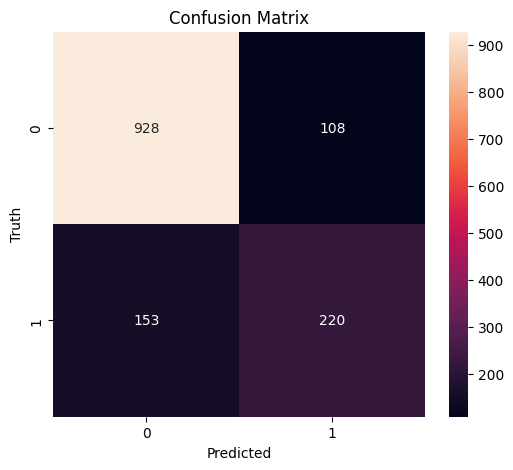

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='rocket',
    xticklabels=[0, 1],
    yticklabels=[0, 1]
)

plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Confusion Matrix")
plt.show()